In [1]:
%matplotlib widget
import matplotlib.pyplot as plt

from scripts import lesion_diagnostics
import os
from pathlib import Path
import pandas as pd
import numpy as np
import nibabel as nib
import json
import pickle as pkl

import scripts.compile_run_metrics
import helpers.utils
import scripts.inference
from IPython.display import clear_output

from reload_recursive import reload_recursive
from tqdm.notebook import tqdm


In [2]:
reload_recursive(scripts.compile_run_metrics)
#TODO Thi
from scripts.compile_run_metrics import EXPERIMENT_KEYS

reload_recursive(scripts.inference)
from scripts.inference import uncrop_predictions

reload_recursive(helpers.utils)
from helpers.utils import dice_score

import core.dataset
reload_recursive(core.dataset)
from core.dataset import Dataset
from core.experiment import Experiment

from scripts import lesion_diagnostics as lesion_dx
from scripts.compile_run_metrics import load_or_cache_run

In [3]:
dataset_name = "roi_train2"
dataset = Dataset(dataset_name)

experiment_key, run_name = "stage3", "run2"
experiment_name = f"{EXPERIMENT_KEYS[experiment_key]}/{run_name}"

experiment_results = load_or_cache_run(dataset_name, experiment_name)
experiment = Experiment.from_run_dir(experiment_name, dataset)

expand_xy: int = experiment.preprocess_config.expand_xy
expand_z: int = experiment.preprocess_config.expand_z
images: tuple[str, ...] = experiment.preprocess_config.images


2026-03-26 20:13:35.729 | DEBUG    | scripts.compile_run_metrics:load_or_cache_run:185 - Loading cached: roi_train2_stage3_numcrops_bkd_constwt115_run2.pkl


In [4]:
experiment.cases

[{'subid': 1293,
  'lesion_index': 1,
  'image': PosixPath('/media/smbshare/srs-9/prl_project/data/sub1293-20161129/1/flair.phase_xy20_z2.nii.gz'),
  'label': PosixPath('/media/smbshare/srs-9/prl_project/data/sub1293-20161129/1/prl_label_SRS_CH_xy20_z2.nii.gz'),
  'split': 'testing',
  'inference': PosixPath('/media/smbshare/srs-9/prl_project/training/roi_train2/stage3_numcrops_bkd_constwt115/run2/ensemble_output/sub1293-20161129/1/flair.phase_xy20_z2_ensemble.nii.gz'),
  'case_type': 'PRL'},
 {'subid': 1074,
  'lesion_index': 3,
  'image': PosixPath('/media/smbshare/srs-9/prl_project/data/sub1074-20190518/3/flair.phase_xy20_z2.nii.gz'),
  'label': PosixPath('/media/smbshare/srs-9/prl_project/data/sub1074-20190518/3/prl_label_CH_xy20_z2.nii.gz'),
  'split': 'testing',
  'inference': PosixPath('/media/smbshare/srs-9/prl_project/training/roi_train2/stage3_numcrops_bkd_constwt115/run2/ensemble_output/sub1074-20190518/3/flair.phase_xy20_z2_ensemble.nii.gz'),
  'case_type': 'PRL'},
 {'subid

In [30]:
import traceback

import math

def analyze_prl_case(prl_case: dict):
    subid = prl_case['subid']
    index = prl_case['lesion_index']
    subject_dir = experiment.dataset.subject_dir(subid)
    data_root = experiment.dataset.data_root

    lesion_index_path = subject_dir / "lstai_lesion_index.nii.gz"
    lesion_index = nib.load(str(lesion_index_path)).get_fdata().astype(np.int32)

    # Parse bounding boxes
    bbox_suffix = f"xy{expand_xy}_z{expand_z}"
    bbox_file = subject_dir / f"lstai_bounding_boxes_{bbox_suffix}.txt"
    bounding_boxes = lesion_diagnostics._parse_bounding_boxes(bbox_file)

    try:
        assert bounding_boxes[index-1][0] == index
    except AssertionError:
        print(index, bounding_boxes[index-1][0])
    coords = bounding_boxes[index-1][1]

    # Load inference output for this ROI
    image_path = data_root / prl_case["image"]
    groundtruth_path = data_root / prl_case["label"]
    infer_path = data_root / prl_case["inference"]
    if not infer_path.exists():
        print(f"Inference output not found: {infer_path}")
        return None
    
    label_keys = ["truth", "infer"]
    lesion_stats = {"lesion_index": index, **{f"rim_voxels_{k}": None for k in label_keys}}
    lesion_data = {"lesion_index": index}
    for id, lab in zip(label_keys, [groundtruth_path, infer_path]):
        lab_nifti = nib.load(str(lab))
        lab_data = lab_nifti.get_fdata().astype(np.uint8)
        voxel_size = lab_nifti.header.get_zooms()[:3]
        voxel_volume = math.prod(voxel_size)

        lesion_data[f"label_{id}"] = lab_data

        # Crop lesion index with the same bounding box
        index_crop = lesion_diagnostics._crop_from_volume(lesion_index, coords)
        lesion_data[f"index_crop_{id}"] = index_crop

        
        #! this basically does the same as below, but i want to be explicit in this loop for reference
        # Connected component analysis to get reliable rim voxel count
        # rim_count = lesion_diagnostics._count_rim_for_lesion(index_crop, lab_data, index)

        try:
            # any iron detection: rim voxels that overlap the central lesion's footprint
            has_iron = np.any((index_crop == index) & (lab_data == 2))
            if id == "infer":
                lesion_stats['has_iron_infer'] = has_iron
            # ---Process Rim---
            # get the rim for the center lesion
            rim = lesion_dx._get_lesion_rim(index_crop, lab_data, index)
            rim_count = int(rim.sum())
            rim_sphere_radius = lesion_dx.rim_enclosing_sphere_radius(rim, voxel_size)

            # get convex hull
            hull = lesion_dx.get_convex_hull(rim, voxel_sizes=voxel_size)
            
            lesion_data.update({
                f"rim_{id}": rim,
                f"rim_hull_{id}": hull,
            })

            lesion_stats.update({
                f"rim_voxels_{id}": rim_count,
                f"rim_volume_{id}": rim_count*voxel_volume,
            })

            lesion_stats.update({
                f"rim_hull_volume_{id}": hull.volume,
                f"rim_sphere_radius_{id}": rim_sphere_radius,
            })
        except Exception:
            print(prl_case['subid'], prl_case['lesion_index'])
            tb_str = traceback.format_exc()
            print(f"Captured Traceback:\n{tb_str}")
            pass


        # ---Process T2 Lesion---
        try:
            lesion = lesion_dx._get_center_lesion(index_crop, lab_data, index)
            lesion_count = int(lesion.sum())

            # get convex hull
            hull = lesion_dx.get_convex_hull(lesion, voxel_sizes=voxel_size)
            
            lesion_data.update({
                f"lesion_{id}": lesion,
                f"lesion_hull_{id}": hull,
            })

            lesion_stats.update({
                f"lesion_voxels_{id}": lesion_count,
                f"lesion_volume_{id}": lesion_count*voxel_volume,
            })
            lesion_stats.update({
                f"lesion_hull_volume_{id}": hull.volume
            })
        except Exception:
            tb_str = traceback.format_exc()
            print(f"Captured Traceback:\n{tb_str}")
            pass

        lesion_data[f"voxel_size_{id}"] = voxel_size    
    return lesion_stats, lesion_data

In [33]:
from collections import defaultdict
import traceback

full_data = defaultdict(list)
for prl_case in tqdm(experiment.cases):
    full_data['case_info'].append(prl_case)
    try:
        prl_stats, prl_data = analyze_prl_case(prl_case)
    except Exception as e:
        exception_name = type(e).__name__
        print(exception_name ,prl_case['subid'], prl_case['lesion_index'])
        tb_str = traceback.format_exc()
        print(f"Captured Traceback:\n{tb_str}")
        continue
    full_data['prl_stats'].append(prl_stats)
    full_data['prl_data'].append(prl_data)

import pickle as pkl

cache_dir = Path("/home/srs-9/Projects/prl_project/analysis/.cache")
cache_dir.exists()
save_path = cache_dir / f"prl_image_stats-{experiment.id.replace('/', '_')}.pkl"
with open(save_path, 'wb') as f:
    pkl.dump(full_data, f)

prl_stats = full_data['prl_stats']
df_data = []
for case_info, case_stats in zip(full_data['case_info'], full_data['prl_stats']):
    df_data.append({**case_info, **case_stats})

df_cases = pd.DataFrame(df_data).set_index(["subid","lesion_index"])

save_path = cache_dir.parent / f"prl_image_stats-{experiment.id.replace('/', '_')}.csv"
df_cases.sort_values(by="case_type", ascending=False).to_csv(save_path)

  0%|          | 0/991 [00:00<?, ?it/s]

1529 20
Captured Traceback:
Traceback (most recent call last):
  File "/tmp/ipykernel_1683648/3355221082.py", line 78, in analyze_prl_case
    f"rim_hull_volume_{id}": hull.volume,
                             ^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'volume'

1529 20
Captured Traceback:
Traceback (most recent call last):
  File "/tmp/ipykernel_1683648/3355221082.py", line 78, in analyze_prl_case
    f"rim_hull_volume_{id}": hull.volume,
                             ^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'volume'

1293 35
Captured Traceback:
Traceback (most recent call last):
  File "/tmp/ipykernel_1683648/3355221082.py", line 78, in analyze_prl_case
    f"rim_hull_volume_{id}": hull.volume,
                             ^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'volume'

1293 35
Captured Traceback:
Traceback (most recent call last):
  File "/tmp/ipykernel_1683648/3355221082.py", line 78, in analyze_prl_case
    f"rim_hu

In [35]:
df_cases[df_cases['has_iron_infer']]

,,image,label,split,inference,case_type,rim_voxels_truth,rim_voxels_infer,rim_volume_truth,rim_hull_volume_truth,rim_sphere_radius_truth,lesion_voxels_truth,lesion_volume_truth,lesion_hull_volume_truth,has_iron_infer,rim_volume_infer,rim_hull_volume_infer,rim_sphere_radius_infer,lesion_voxels_infer,lesion_volume_infer,lesion_hull_volume_infer
subid,lesion_index,,,,,,,,,,,,,,,,,,,,
1293,1,/media/smbshare/srs-9/prl_project/data/sub1293...,/media/smbshare/srs-9/prl_project/data/sub1293...,testing,/media/smbshare/srs-9/prl_project/training/roi...,PRL,291,553,148.991623,562.003893,9.780741,6872,3518.455078,13428.018917,True,283.135284,4804.510353,33.119401,6410,3281.911865,13401.053653
1074,3,/media/smbshare/srs-9/prl_project/data/sub1074...,/media/smbshare/srs-9/prl_project/data/sub1074...,testing,/media/smbshare/srs-9/prl_project/training/roi...,PRL,179,221,91.648346,154.795250,5.280144,247,126.464478,126.976479,True,113.152428,160.256604,7.301470,271,138.752518,138.752523
1080,3,/media/smbshare/srs-9/prl_project/data/sub1080...,/media/smbshare/srs-9/prl_project/data/sub1080...,testing,/media/smbshare/srs-9/prl_project/training/roi...,PRL,191,250,97.787178,181.751030,5.386045,371,189.942627,224.500920,True,127.993690,201.291399,6.570507,273,139.769104,160.333420
2131,1,/media/smbshare/srs-9/prl_project/data/sub2131...,/media/smbshare/srs-9/prl_project/data/sub2131...,testing,/media/smbshare/srs-9/prl_project/training/roi...,PRL,616,799,315.391205,785.064655,8.130503,1405,719.358215,864.339118,True,409.086975,885.160398,8.769119,1308,669.694336,827.048547
1011,7,/media/smbshare/srs-9/prl_project/data/sub1011...,/media/smbshare/srs-9/prl_project/data/sub1011...,testing,/media/smbshare/srs-9/prl_project/training/roi...,PRL,189,363,96.762184,200.606598,5.626882,343,175.605438,174.496169,True,185.844818,288.835957,5.710685,271,138.743652,132.685351
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1050,2,/media/smbshare/srs-9/prl_project/data/sub1050...,/media/smbshare/srs-9/prl_project/data/sub1050...,fold2,/media/smbshare/srs-9/prl_project/training/roi...,Lesion,0,285,0.000000,NaN,NaN,1833,938.462830,1217.834378,True,145.914841,623.508674,9.910973,1721,881.120850,1337.979473
1038,3,/media/smbshare/srs-9/prl_project/data/sub1038...,/media/smbshare/srs-9/prl_project/data/sub1038...,fold1,/media/smbshare/srs-9/prl_project/training/roi...,Lesion,0,19,0.000000,NaN,NaN,703,359.937347,446.636350,True,9.728037,36.522804,5.501122,549,281.089050,380.246767
1050,26,/media/smbshare/srs-9/prl_project/data/sub1050...,/media/smbshare/srs-9/prl_project/data/sub1050...,fold0,/media/smbshare/srs-9/prl_project/training/roi...,Lesion,0,4,0.000000,NaN,NaN,141,72.189445,48.467624,True,2.047928,NaN,NaN,174,89.084854,61.693824


In [ ]:
import pickle as pkl

cache_dir = Path("/home/srs-9/Projects/prl_project/analysis/.cache")
cache_dir.exists()
save_path = cache_dir / f"prl_image_stats-{experiment.id.replace('/', '_')}.pkl"
with open(save_path, 'wb') as f:
    pkl.dump(full_data, f)

prl_stats = full_data['prl_stats']
df_data = []
for case_info, case_stats in zip(full_data['case_info'], full_data['prl_stats']):
    df_data.append({**case_info, **case_stats})

df_cases = pd.DataFrame(df_data).set_index(["subid","lesion_index"])

save_path = cache_dir.parent / f"prl_image_stats-{experiment.id.replace('/', '_')}.csv"
df_cases.sort_values(by="case_type", ascending=False).to_csv(save_path)

In [12]:
save_path = cache_dir / f"prl_image_stats-{experiment.id.replace('/', '_')}.pkl"
with open(save_path, 'rb') as f:
    full_data = pkl.load(f)

In [38]:
import math
import scripts.lesion_diagnostics
reload_recursive(scripts.lesion_diagnostics)
import scripts.lesion_diagnostics as lesion_dx

subid = 1011
cases = pd.DataFrame(experiment.cases).set_index(["subid", "lesion_index"])


subject_dir = experiment.dataset.subject_dir(subid)
data_root = experiment.dataset.data_root

lesion_index_path = subject_dir / "lstai_lesion_index.nii.gz"
lesion_index = nib.load(str(lesion_index_path)).get_fdata().astype(np.int32)

# Parse bounding boxes
bbox_suffix = f"xy{expand_xy}_z{expand_z}"
bbox_file = subject_dir / f"lstai_bounding_boxes_{bbox_suffix}.txt"
bounding_boxes = lesion_diagnostics._parse_bounding_boxes(bbox_file)

prl_stats = []
prl_data = []
i = 0
for index, coords in bounding_boxes:
    # Load inference output for this ROI
    image_path = data_root / cases.loc[(subid,index), "image"]
    groundtruth_path = data_root / cases.loc[(subid,index), "label"]
    infer_path = data_root / cases.loc[(subid,index), "inference"]
    if not infer_path.exists():
        print(f"Inference output not found: {infer_path}")
        continue
    label_keys = ["truth", "infer"]
    lesion_stats = {"lesion_index": index, **{f"rim_voxels_{k}": None for k in label_keys}}
    lesion_data = {"lesion_index": index}
    for id, lab in zip(label_keys, [groundtruth_path, infer_path]):
        lab_nifti = nib.load(str(lab))
        lab_data = lab_nifti.get_fdata().astype(np.uint8)
        voxel_size = lab_nifti.header.get_zooms()[:3]
        voxel_volume = math.prod(voxel_size)

        lesion_data[f"label_{id}"] = lab_data

        # Crop lesion index with the same bounding box
        index_crop = lesion_diagnostics._crop_from_volume(lesion_index, coords)
        lesion_data[f"index_crop_{id}"] = index_crop

        # any iron detection: rim voxels that overlap the central lesion's footprint
        has_iron = np.any((index_crop == index) & (lab_data == 2))
        if not has_iron:
            continue
        
        #! this basically does the same as below, but i want to be explicit in this loop for reference
        # Connected component analysis to get reliable rim voxel count
        # rim_count = lesion_diagnostics._count_rim_for_lesion(index_crop, lab_data, index)

        # ---Process Rim---
        # get the rim for the center lesion
        rim = lesion_dx._get_lesion_rim(index_crop, lab_data, index)
        rim_count = int(rim.sum())

        # get convex hull
        hull = lesion_dx.get_convex_hull(rim, voxel_sizes=voxel_size)
        
        lesion_data.update({
            f"rim_{id}": rim,
            f"rim_hull_{id}": hull,
        })

        lesion_stats.update({
            f"rim_voxels_{id}": rim_count,
            f"rim_volume_{id}": rim_count*voxel_volume,
            f"rim_hull_volume_{id}": hull.volume
        })

        # ---Process T2 Lesion---
        lesion = lesion_dx._get_center_lesion(index_crop, lab_data, index)
        lesion_count = int(lesion.sum())

        # get convex hull
        hull = lesion_dx.get_convex_hull(lesion, voxel_sizes=voxel_size)
        
        lesion_data.update({
            f"lesion_{id}": lesion,
            f"lesion_hull_{id}": hull,
        })

        lesion_stats.update({
            f"lesion_voxels_{id}": lesion_count,
            f"lesion_volume_{id}": lesion_count*voxel_volume,
            f"lesion_hull_volume_{id}": hull.volume
        })

    lesion_data[f"voxel_size"] = voxel_size

    if any([lesion_stats[f"rim_voxels_{k}"] for k in label_keys]):
    # if len(lesion_stats.keys()) > 1:  
        prl_stats.append(lesion_stats)
        prl_data.append(lesion_data)
prl_stats

# bbox_suffix = f"xy{expand_xy}_z{expand_z}"
# bbox_file = subject_dir / f"lstai_bounding_boxes_{bbox_suffix}.txt"
# bounding_boxes = lesion_dx._parse_bounding_boxes(bbox_file)

# lesion_index_path = subject_dir / "lstai_lesion_index.nii.gz"
# lesion_index = nib.load(str(lesion_index_path)).get_fdata().astype(np.int32)

# index = 1



[{'lesion_index': 1,
  'rim_voxels_truth': 272,
  'rim_voxels_infer': 359,
  'rim_volume_truth': np.float32(139.25563),
  'rim_hull_volume_truth': 287.98267507630476,
  'lesion_voxels_truth': 744,
  'lesion_volume_truth': np.float32(380.9051),
  'lesion_hull_volume_truth': 474.2541357256596,
  'rim_volume_infer': np.float32(183.79695),
  'rim_hull_volume_infer': 427.4942821132703,
  'lesion_voxels_infer': 739,
  'lesion_volume_infer': np.float32(378.34525),
  'lesion_hull_volume_infer': 463.67343892285623},
 {'lesion_index': 2,
  'rim_voxels_truth': None,
  'rim_voxels_infer': 185,
  'rim_volume_infer': np.float32(94.7143),
  'rim_hull_volume_infer': 234.73787826219672,
  'lesion_voxels_infer': 621,
  'lesion_volume_infer': np.float32(317.9329),
  'lesion_hull_volume_infer': 479.6298123270838},
 {'lesion_index': 3,
  'rim_voxels_truth': 120,
  'rim_voxels_infer': 139,
  'rim_volume_truth': np.float32(61.436306),
  'rim_hull_volume_truth': 99.57800942638447,
  'lesion_voxels_truth': 620

In [14]:
len(full_data['prl_stats'])

47

In [89]:
lesion_dx.rim_enclosing_sphere_radius(rim, voxel_size)


6.363795631657908

In [88]:
subid = 11
index = 1

index, coords = bounding_boxes[0]
which_label = "label"
lab_path = cases.loc[(subid,index), which_label]
lab_data = nib.load(str(lab_path)).get_fdata().astype(np.uint8)
index_crop = lesion_dx._crop_from_volume(lesion_index, coords)
rim = lesion_dx._get_lesion_rim(index_crop, lab_data, index)
voxel_size = nib.load(str(infer_path)).header.get_zooms()[:3]
lesion_dx.rim_enclosing_sphere_radius(rim, voxel_size)


KeyError: (11, 1)

Need
- bounding_boxes
- cases
- lesion_index (can get )

Index a case with subid and lesion_index

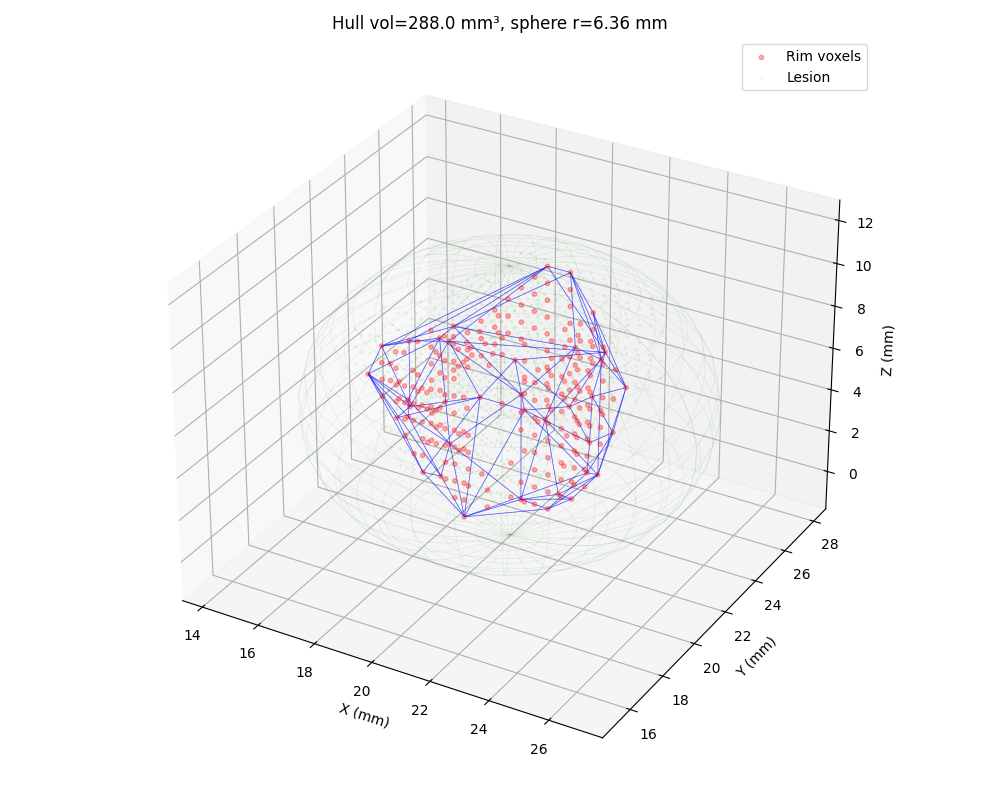

In [47]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial import ConvexHull

index = 1
prl_case = prl_data[index-1]

klab = "truth"
rim = prl_case[f"rim_{klab}"]
voxel_size = prl_case['voxel_size']
# Rim voxel coordinates in mm
coords = np.argwhere(rim) * np.array(voxel_size)

# Convex hull
hull = prl_case[f"rim_hull_{klab}"]

# Enclosing sphere (same approach as the function)
vertices = coords[hull.vertices]
center = vertices.mean(axis=0)
radius = np.max(np.linalg.norm(vertices - center, axis=1))

# --- Plot ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Rim voxels
ax.scatter(*coords.T, c='red', alpha=0.3, s=10, label='Rim voxels')

# Convex hull faces
for simplex in hull.simplices:
    pts = coords[simplex]
    # Close the triangle
    tri = np.vstack([pts, pts[0]])
    ax.plot(*tri.T, 'b-', alpha=0.4, linewidth=0.5)

# Enclosing sphere wireframe
u = np.linspace(0, 2 * np.pi, 30)
v = np.linspace(0, np.pi, 20)
x = center[0] + radius * np.outer(np.cos(u), np.sin(v))
y = center[1] + radius * np.outer(np.sin(u), np.sin(v))
z = center[2] + radius * np.outer(np.ones_like(u), np.cos(v))
ax.plot_wireframe(x, y, z, color='green', alpha=0.15, linewidth=0.3)

# Also show lesion voxels for context (label=1 from infer_data)
lesion_coords = np.argwhere(prl_case[f'lesion_{klab}'] == 1) * np.array(voxel_size)
# lesion_coords = np.argwhere(lab_data == 1) * np.array(voxel_size)
ax.scatter(*lesion_coords.T, c='green', alpha=0.05, s=2, label='Lesion')

ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')
ax.set_zlabel('Z (mm)')
ax.legend()
ax.set_title(f'Hull vol={hull.volume:.1f} mm³, sphere r={radius:.2f} mm')
plt.tight_layout()
plt.show()


In [ ]:
image_paths = [subject_root / "flair.nii.gz", subject_root / "phase.nii.gz"]
labels = [subject_root / f"prl_inference_{experiment_id}.nii.gz"]
assert labels[0].exists()
subprocess.run(open_itksnap_workspace_cmd(image_paths, labels), shell=True)
clear_output()

In [ ]:
subject_dir: Path = Path("/media/smbshare/srs-9/prl_project/data/sub1011-20180911")

expand_xy: int = 20
expand_z: int = 2

data_root: Path = Path("/media/smbshare/srs-9/prl_project/data")
infer_output_dir = data_root
images: tuple[str, ...] = ["flair", "phase"]

def load_experiment(exp_name, run_name):
    path = cache_dir / f"{EXPERIMENT_KEYS[exp_name]}_{run_name}.pkl"
    with open(path, 'rb') as f:
        exp_data = pkl.load(f)
    return exp_data

experiment = load_experiment(experiment_key, run_name)
cases = pd.DataFrame(experiment['cases']).set_index(["subid", "lesion_index"])

with open("/home/srs-9/Projects/prl_project/training/roi_train2/datalist_flair.phase_xy20_z2.json", 'r') as f:
    datalist = json.load(f)
    
datalist_df = pd.DataFrame((datalist['training']+datalist['testing'])).set_index(["subid", "lesion_index"])

In [10]:
# Load lesion index once
subid = 1011
subject_dir = (data_root / datalist_df.loc[subid, "image"].iloc[0]).parent.parent
lesion_index_path = subject_dir / "lstai_lesion_index.nii.gz"
lesion_index = nib.load(str(lesion_index_path)).get_fdata().astype(np.int32)

# Parse bounding boxes
bbox_suffix = f"xy{expand_xy}_z{expand_z}"
bbox_file = subject_dir / f"lstai_bounding_boxes_{bbox_suffix}.txt"
bounding_boxes = lesion_diagnostics._parse_bounding_boxes(bbox_file)

# Build inference output filename pattern
image_basenames = sorted(images)
image_prefix = ".".join(image_basenames) + "_"
# going to need to get the appropriate datalist for suffxes and stuff
label_filename = f"{image_prefix}{bbox_suffix}.nii.gz"
subject_rel = subject_dir.relative_to(data_root)

In [11]:
# reload_recursive(scripts.inference)
# from scripts.inference import uncrop_predictions

# with open("/home/srs-9/Projects/prl_project/training/roi_train2/subjects.txt", 'r') as f:
#     subjects = [sub.strip() for sub in f.readlines()]

# for subid in subjects:
#     subid = int(subid)
#     subject_root = Path(cases.loc[subid, "image"].iloc[0]).parent.parent
#     infer_filepaths = {}
#     for index, row in cases.loc[subid].iterrows():
#         infer_filepaths[index] = row.loc["inference"]

#     uncrop_predictions(subject_root, expand_xy, expand_z, data_root, ["flair", "phase"], experiment_id, infer_filepaths=infer_filepaths)

In [13]:

subid = 1011
subject_root = Path(cases.loc[subid, "image"].iloc[0]).parent.parent
lesion_index_path = subject_dir / "lstai_lesion_index.nii.gz"
lesion_index = nib.load(str(lesion_index_path)).get_fdata().astype(np.int32)

# Parse bounding boxes
bbox_suffix = f"xy{expand_xy}_z{expand_z}"
bbox_file = subject_dir / f"lstai_bounding_boxes_{bbox_suffix}.txt"
bounding_boxes = lesion_diagnostics._parse_bounding_boxes(bbox_file)

# Build inference output filename pattern
image_basenames = sorted(images)
image_prefix = ".".join(image_basenames) + "_"
# going to need to get the appropriate datalist for suffxes and stuff
label_filename = f"{image_prefix}{bbox_suffix}.nii.gz"
subject_rel = subject_dir.relative_to(data_root)


prls = []
i = 0
for index, coords in bounding_boxes:
    # Load inference output for this ROI
    image_path = data_root / cases.loc[(subid,index), "image"]
    groundtruth_path = data_root / cases.loc[(subid,index), "label"]
    infer_path = data_root / cases.loc[(subid,index), "inference"]
    if not infer_path.exists():
        print(f"Inference output not found: {infer_path}")
        continue
    label_keys = ["truth", "infer"]
    lesion_dx = {"lesion_index": index, **{f"rim_voxels_{k}": None for k in label_keys}}
    for id, lab in zip(label_keys, [groundtruth_path, infer_path]):
        lab_data = nib.load(str(lab)).get_fdata().astype(np.uint8)

        # Crop lesion index with the same bounding box
        index_crop = lesion_diagnostics._crop_from_volume(lesion_index, coords)

        # any iron detection: rim voxels that overlap the central lesion's footprint
        has_iron = np.any((index_crop == index) & (lab_data == 2))

        if has_iron:
            # Connected component analysis to get reliable rim voxel count
            rim_count = lesion_diagnostics._count_rim_for_lesion(index_crop, lab_data, index)
            lesion_dx.update({f"rim_voxels_{id}": rim_count})

    if any([lesion_dx[f"rim_voxels_{k}"] for k in label_keys]):
    # if len(lesion_dx.keys()) > 1:  
        prls.append(lesion_dx)
prls

[{'lesion_index': 1, 'rim_voxels_truth': 272, 'rim_voxels_infer': 359},
 {'lesion_index': 2, 'rim_voxels_truth': None, 'rim_voxels_infer': 185},
 {'lesion_index': 3, 'rim_voxels_truth': 120, 'rim_voxels_infer': 139},
 {'lesion_index': 4, 'rim_voxels_truth': 345, 'rim_voxels_infer': 477},
 {'lesion_index': 5, 'rim_voxels_truth': None, 'rim_voxels_infer': 21},
 {'lesion_index': 6, 'rim_voxels_truth': 165, 'rim_voxels_infer': 210},
 {'lesion_index': 7, 'rim_voxels_truth': 189, 'rim_voxels_infer': 363},
 {'lesion_index': 8, 'rim_voxels_truth': None, 'rim_voxels_infer': 7},
 {'lesion_index': 10, 'rim_voxels_truth': None, 'rim_voxels_infer': 57},
 {'lesion_index': 12, 'rim_voxels_truth': 94, 'rim_voxels_infer': 49},
 {'lesion_index': 16, 'rim_voxels_truth': None, 'rim_voxels_infer': 49},
 {'lesion_index': 19, 'rim_voxels_truth': None, 'rim_voxels_infer': 5}]

In [14]:
import subprocess
from helpers.shell_interface import open_itksnap_workspace_cmd
index = 2
image_path = data_root / cases.loc[(subid,index), "image"]
groundtruth_path = data_root / cases.loc[(subid,index), "label"]
infer_path = data_root / cases.loc[(subid,index), "inference"]
label_keys = ["truth", "infer"]
labels = []
for id, lab in zip(label_keys, [groundtruth_path, infer_path]):
    labels.append(lab)
suffix = f"_xy{expand_xy}_z{expand_z}.nii.gz"
ims = ["flair", "phase"]
image_paths = []
for im in ims:
    name = f"{im}{suffix}"
    path = image_path.parent / name
    print(path)
    assert path.exists()
    image_paths.append(path)

subprocess.run(open_itksnap_workspace_cmd(image_paths, labels), shell=True)
clear_output()

- Convex Hull
- A sphere that encompasses the PRL voxels

In [ ]:
image_paths = [subject_root / "flair.nii.gz", subject_root / "phase.nii.gz"]
labels = [subject_root / f"prl_inference_{experiment_id}.nii.gz"]
assert labels[0].exists()
subprocess.run(open_itksnap_workspace_cmd(image_paths, labels), shell=True)
clear_output()

In [ ]:
import scripts.lesion_diagnostics as lesion_dx

subid = 1011
subject_root = Path(cases.loc[subid, "image"].iloc[0]).parent.parent
lesion_index_path = subject_dir / "lstai_lesion_index.nii.gz"
lesion_index = nib.load(str(lesion_index_path)).get_fdata().astype(np.int32)

# Parse bounding boxes
bbox_suffix = f"xy{expand_xy}_z{expand_z}"
bbox_file = subject_dir / f"lstai_bounding_boxes_{bbox_suffix}.txt"
bounding_boxes = lesion_diagnostics._parse_bounding_boxes(bbox_file)

# Build inference output filename pattern
image_basenames = sorted(images)
image_prefix = ".".join(image_basenames) + "_"
# going to need to get the appropriate datalist for suffxes and stuff
label_filename = f"{image_prefix}{bbox_suffix}.nii.gz"
subject_rel = subject_dir.relative_to(data_root)


prls = []
i = 0
for index, coords in bounding_boxes:
    # Load inference output for this ROI
    image_path = data_root / cases.loc[(subid,index), "image"]
    groundtruth_path = data_root / cases.loc[(subid,index), "label"]
    infer_path = data_root / cases.loc[(subid,index), "inference"]
    if not infer_path.exists():
        print(f"Inference output not found: {infer_path}")
        continue
    label_keys = ["truth", "infer"]
    lesion_dx = {"lesion_index": index, **{f"rim_voxels_{k}": None for k in label_keys}}
    for id, lab in zip(label_keys, [groundtruth_path, infer_path]):
        lab_data = nib.load(str(lab)).get_fdata().astype(np.uint8)

        # Crop lesion index with the same bounding box
        index_crop = lesion_diagnostics._crop_from_volume(lesion_index, coords)

        # any iron detection: rim voxels that overlap the central lesion's footprint
        has_iron = np.any((index_crop == index) & (lab_data == 2))

        if has_iron:
            rim

    if any([lesion_dx[f"rim_voxels_{k}"] for k in label_keys]):
    # if len(lesion_dx.keys()) > 1:  
        prls.append(lesion_dx)
prls

/media/smbshare/srs-9/prl_project/data/sub1011-20180911/32/flair_xy20_z2.nii.gz
/media/smbshare/srs-9/prl_project/data/sub1011-20180911/32/phase_xy20_z2.nii.gz
